# 特征匹配

## 1. 特征匹配的原理与流程

**特征匹配**（Feature Matching）是根据特征描述符的相似性，在两幅图像中建立对应关系的过程。

**特征匹配的完整流程：**

> **图片引用：**
> 典型的特征提取与匹配流程图：
> 
<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251111103727295.png" width="800px"/></div>
</div>


1.  **特征提取**：在图像 A 和图像 B 中分别检测关键点 $KP_A, KP_B$ 并计算描述符 $D_A, D_B$。
2.  **相似度计算**：选择合适的距离度量（如欧氏距离或汉明距离），计算 $D_A$ 中每个描述符与 $D_B$ 中所有描述符的相似度。
3.  **初步匹配**：根据相似度找到最佳匹配对。
4.  **匹配筛选**：使用几何约束或统计方法（如 RANSAC 或比率测试）去除错误匹配。
5.  **应用**：利用筛选后的匹配对计算图像间的变换矩阵，实现图像拼接、目标定位等。

## 2. 暴力匹配 (Brute-Force Matcher) 及其距离度量

暴力匹配是一种简单直接的匹配方法，它遍历所有特征点的描述符，并计算它们之间的距离。然后根据距离进行排序，选择距离最短的特征点作为匹配点。虽然暴力匹配方法简单，但在特征点数量较大时计算开销较大。暴力匹配的具体步骤如下：
1. 特征点检测：首先，使用特征检测算法（如SIFT、SURF、ORB等）在图像中检测出关键点。这些关键点通常位于图像中的显著位置，如角点、边缘等。
2. 特征描述：对于每个检测到的关键点，计算其周围像素的特征描述符。这些描述符是一组向量，用于描述关键点周围的图像信息。常见的特征描述算法包括SIFT描述符、SURF描述符、ORB描述符等。
3. 特征匹配：将一组特征点的描述符与另一组特征点的描述符进行匹配。常见的方法是计算描述符之间的距离（如欧氏距离、汉明距离等），并选择距离最近的特征点作为匹配点。
4. 匹配筛选：对匹配结果进行筛选和排序，通常根据距离进行排序，选择距离最短的特征点作为最佳匹配点。可以使用阈值或其他筛选方法来排除不可靠的匹配。
5. 匹配验证和优化：对匹配结果进行验证和优化，例如使用RANSAC算法进行模型拟合和外点剔除，以提高匹配的准确性和鲁棒性。


### 2.1 距离度量

选择正确的距离度量对于匹配至关重要：

| 描述符类型 | 匹配距离 | 计算公式/方法 | 适用场景 |
| :--- | :--- | :--- | :--- |
| **浮点型** (SIFT, SURF) | **欧氏距离** (L2 范数) | $d(x, y) = \sqrt{\sum_{i} (x_i - y_i)^2}$ | 描述符维度较高，数值连续。 |
| **二值型** (ORB, BRIEF) | **汉明距离** (Hamming Distance) | 统计两个二值向量中不同位的数量。 | 描述符维度较低，数值为 0 或 1。 |


## 3. 匹配结果筛选：距离比率测试 (Ratio Test)

由于图像中存在大量相似的纹理和重复结构，暴力匹配会产生大量的**误匹配**（False Matches）。距离比率测试是去除误匹配的有效方法。

**Lowe's Ratio Test 原理：**

对于图像 A 中的描述符 $D_A$，找到图像 B 中与它：
*   **最近邻**（Best Match）：$D_{B1}$，距离为 $d_1$。
*   **次近邻**（Second Best Match）：$D_{B2}$，距离为 $d_2$。

如果 $d_1 / d_2 < \text{Ratio}$（通常取 0.7 到 0.8），则接受该匹配；否则，拒绝。

**逻辑解释：**

*   如果 $d_1$ 远小于 $d_2$（比值很小），说明 $D_A$ 与 $D_{B1}$ 的相似度远高于与 $D_{B2}$ 的相似度，匹配具有**高置信度**。
*   如果 $d_1$ 接近 $d_2$（比值接近 1），说明 $D_A$ 与 $D_{B1}$ 和 $D_{B2}$ 都很相似，无法明确区分，很可能是**误匹配**，应舍弃。

## 4. 代码示例：ORB 特征提取与匹配（完整模拟）

这个示例将模拟一个完整的 ORB 特征提取、描述和匹配过程，并演示如何使用距离比率测试进行筛选。


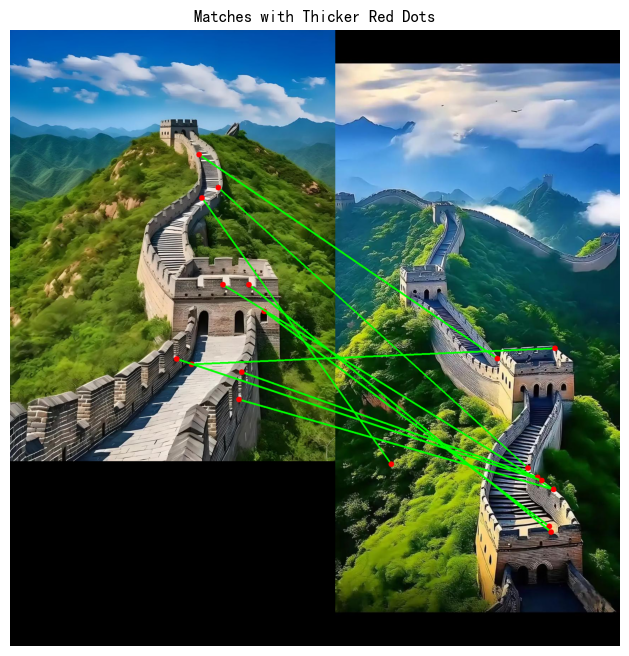

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取两张图像
img1 = cv2.imread('2.jpg')
img2 = cv2.imread('3.jpeg')

# 检查图像是否正确加载

if img1 is None or img2 is None:
    raise FileNotFoundError("图像文件未找到，请检查路径是否正确！")

# 初始化ORB特征点检测器
orb = cv2.ORB_create()

# 检测特征点与描述符
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# 创建蛮力（BF）匹配器
bf = cv2.BFMatcher_create(cv2.NORM_HAMMING, crossCheck=True)

# 匹配描述符
matches = bf.match(des1, des2)

# 按距离排序，距离越小匹配越好
matches = sorted(matches, key=lambda x: x.distance)

# 创建一个空白画布，将两张图像水平拼接
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1
canvas[:h2, w1:w1 + w2] = img2

# 绘制匹配点和匹配线
for match in matches[:10]:  # 只绘制前10个匹配点
    pt1 = tuple(map(int, kp1[match.queryIdx].pt))
    pt2 = tuple(map(int, kp2[match.trainIdx].pt))
    pt2 = (pt2[0] + w1, pt2[1])  # 调整第二张图像的坐标

    # 绘制匹配线，设置线条粗细为3
    cv2.line(canvas, pt1, pt2, (0, 255, 0), thickness=3)
    
    # 绘制关键点圆圈，将半径设置为8
    cv2.circle(canvas, pt1, 8, (0, 0, 255), -1)  # 绘制关键点圆圈，更粗的红色圆点
    cv2.circle(canvas, pt2, 8, (0, 0, 255), -1)  # 绘制关键点圆圈，更粗的红色圆点

# 在 Jupyter Notebook 中显示图像
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Matches with Thicker Red Dots")
plt.axis('off')
plt.show()

运行上述代码后，我们能看到两张图像之间的前 10 个匹配特征点的可视化结果。

这十个匹配特征点看上去并非能够匹配的上，这是因为匹配结果是基于描述符的相似性，而不是基于图像的整体内容或语义信息。          
因此，即使两张图像的内容完全不同，只要它们有相似的局部纹理或边缘特征，就可能会出现匹配点。


那么我们尝试一下使用同一张图片进行匹配。

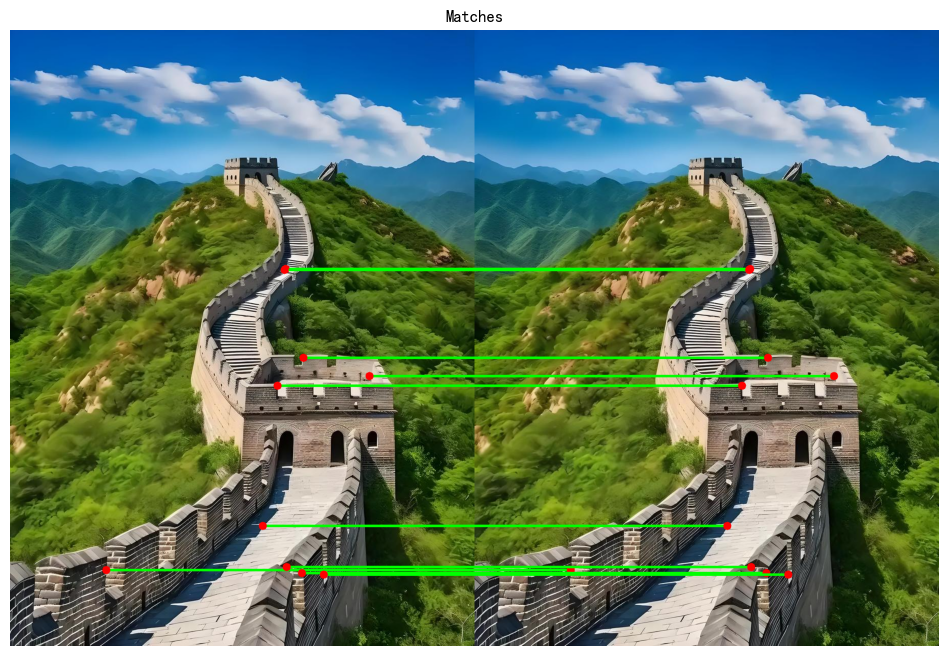

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取两张图像
img1 = cv2.imread('2.jpg')
img2 = cv2.imread('2.jpg')

# 检查图像是否正确加载

if img1 is None or img2 is None:
    raise FileNotFoundError("图像文件未找到，请检查路径是否正确！")

# 初始化ORB特征点检测器
orb = cv2.ORB_create()

# 检测特征点与描述符
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# 创建蛮力（BF）匹配器
bf = cv2.BFMatcher_create(cv2.NORM_HAMMING, crossCheck=True)

# 匹配描述符
matches = bf.match(des1, des2)

# 按距离排序，距离越小匹配越好
matches = sorted(matches, key=lambda x: x.distance)

# 创建一个空白画布，将两张图像水平拼接
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1
canvas[:h2, w1:w1 + w2] = img2

# 绘制匹配点和匹配线
for match in matches[:10]:  # 只绘制前10个匹配点
    pt1 = tuple(map(int, kp1[match.queryIdx].pt))
    pt2 = tuple(map(int, kp2[match.trainIdx].pt))
    pt2 = (pt2[0] + w1, pt2[1])  # 调整第二张图像的坐标

    # 绘制匹配线，设置线条粗细为3
    cv2.line(canvas, pt1, pt2, (0, 255, 0), thickness=3)
    
    # 绘制关键点圆圈，将半径设置为8
    cv2.circle(canvas, pt1, 8, (0, 0, 255), -1)  # 绘制关键点圆圈，更粗的红色圆点
    cv2.circle(canvas, pt2, 8, (0, 0, 255), -1)  # 绘制关键点圆圈，更粗的红色圆点

# 在 Jupyter Notebook 中显示图像
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Matches")
plt.axis('off')
plt.show()

我们能看到这两张图的 10 个匹配特征点一模一样，非常清晰的展示了匹配的结果。

### 代码功能概述
这段代码使用了 OpenCV 的 ORB（Oriented FAST and Rotated BRIEF）特征检测器来提取两张图像）的特征点和描述符，然后通过蛮力（BF）匹配器对这些描述符进行匹配。最终，代码将匹配结果可视化，显示了两张图像之间的匹配点和匹配线。

### 特征匹配结果的解释
1. **特征点的提取**：
   - ORB 特征检测器在两张图像中分别提取了关键点（特征点）和描述符。这些关键点通常是图像中具有独特纹理或边缘的区域，例如物体的轮廓、角点、边缘等。
   - 特征点的描述符是一个向量，用于描述该点周围的局部图像特征。

2. **匹配原理**：
   - 蛮力匹配器（BFMatcher）通过计算描述符之间的汉明距离（`cv2.NORM_HAMMING`）来判断两个特征点是否匹配。汉明距离越小，表示两个描述符越相似，匹配的可能性越高。
   - 匹配结果是基于描述符的相似性，而不是基于图像的整体内容或语义信息。因此，即使两张图像的内容完全不同，只要它们有相似的局部纹理或边缘特征，就可能会出现匹配点。

3. **匹配结果的可能原因**：
   - **相似的纹理或边缘**：如果两张图像中存在相似的纹理或边缘模式（例如，两幅图像中都有类似的线条、图案或纹理），即使它们的语义内容不同，也会出现匹配点。
   - **重复的局部特征**：某些局部特征可能在不同图像中重复出现，例如常见的几何形状（如圆形、方形）、重复的纹理等。
   - **噪声或伪影**：图像中的噪声或伪影也可能导致误匹配，尤其是在特征描述符不够独特时。

4. **匹配结果的局限性**：
   - 特征匹配仅依赖于局部特征的相似性，而不考虑图像的整体语义或上下文。因此，即使两张图像在视觉上完全不同，只要它们有相似的局部特征，就会出现匹配点。
   - 匹配结果的质量还取决于特征检测器和匹配器的参数设置，例如 ORB 的特征点数量、BFMatcher 的距离阈值等。

### 总结
特征匹配的结果是基于局部特征的相似性，而不是基于图像的整体内容或语义。因此，即使两张图像在视觉上完全不同，只要它们有相似的局部纹理、边缘或几何形状，就会出现匹配点。这种匹配结果在某些情况下可能很有用（例如图像拼接、目标检测等），但在其他情况下可能需要进一步筛选或结合其他信息来验证匹配的可靠性。